# Visualización: Ingresos Brutos por Producto y Estación del Año
### Región Metropolitana de Santiago — Mercado Mayorista (2022–2026)

---

**Pregunta de investigación:**  
*¿Qué productos de mayor volumen generan más ingresos brutos por época del año?*


In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Paleta de colores por estación (hemisferio sur)
SEASON_COLORS = {
    'Verano':    '#F4A261',   # naranja cálido
    'Otoño':     '#E76F51',   # terracota
    'Invierno':  '#457B9D',   # azul frío
    'Primavera': '#52B788',   # verde fresco
}
SEASON_ORDER = ['Verano', 'Otoño', 'Invierno', 'Primavera']

print('Librerías cargadas ✓')

Librerías cargadas ✓


### 1. Carga y preparación de datos
Se reutiliza el `frutas_rm` ya procesado con las columnas `Month`, `Season` e `Ingreso Bruto`.

In [37]:
fruta_2022 = pd.read_csv('precio_mayorista_fruta-hortaliza_2022.csv', decimal=',')
fruta_2023 = pd.read_csv('precio_mayorista_fruta-hortaliza_2023.csv', decimal=',')
fruta_2024 = pd.read_csv('precio_mayorista_fruta-hortaliza_2024.csv', decimal=',')
fruta_2025 = pd.read_csv('precio_mayorista_fruta-hortaliza_2025.csv', decimal=',')
fruta_2026 = pd.read_csv('precio_mayorista_fruta-hortaliza_2026.csv', decimal=',')

fruta_data = pd.concat([
    fruta_2022.dropna(how='all'),
    fruta_2023.dropna(how='all'),
    fruta_2024.dropna(how='all'),
    fruta_2025.dropna(how='all'),
    fruta_2026.dropna(how='all'),
], ignore_index=True).loc[:, [
    'Fecha','ID region','Region','Mercado','Subsector',
    'Producto','Variedad / Tipo','Calidad','Unidad de comercializacion',
    'Origen','Volumen','Precio minimo','Precio maximo','Precio promedio'
]]

frutas_rm = fruta_data[fruta_data['Region'] == 'Región Metropolitana de Santiago'].copy()

# ── Columnas derivadas ──────────────────────────────────────────────────────
frutas_rm['Fecha'] = pd.to_datetime(frutas_rm['Fecha'])
frutas_rm['Month'] = frutas_rm['Fecha'].dt.month
mmdd = frutas_rm['Fecha'].dt.month * 100 + frutas_rm['Fecha'].dt.day

condiciones = [
    (mmdd >= 1221) | (mmdd < 320),
    (mmdd >= 320)  & (mmdd < 621),
    (mmdd >= 621)  & (mmdd <= 921),
    (mmdd >= 922)  & (mmdd < 1221),
]
frutas_rm['Season']       = np.select(condiciones, SEASON_ORDER, default='Fecha inválida')
frutas_rm['Ingreso Bruto'] = frutas_rm['Volumen'] * (frutas_rm['Precio promedio'] / 10000)

print(f'Registros RM: {len(frutas_rm):,}  |  Productos únicos: {frutas_rm["Producto"].nunique()}')
frutas_rm[['Fecha','Producto','Season','Volumen','Precio promedio','Ingreso Bruto']].head()

Registros RM: 315,109  |  Productos únicos: 75


,Fecha,Producto,Season,Volumen,Precio promedio,Ingreso Bruto
2,2022-01-03,Acelga,Verano,60,18000.0000,108.0
5,2022-01-03,Acelga,Verano,30,16000.0000,48.0
7,2022-01-03,Ají,Verano,43,23534.8837,101.2
10,2022-01-03,Ají,Verano,22,42727.2727,94.0
11,2022-01-03,Ají,Verano,44,48181.8181,212.0


### 2. Agregación: Top 10 productos por Ingreso Bruto total

In [38]:
# Top 10 productos por ingreso bruto acumulado
top10 = (
    frutas_rm.groupby('Producto')['Ingreso Bruto']
    .sum()
    .nlargest(10)
    .index.tolist()
)

# Tabla pivot: producto × estación
df_top = frutas_rm[frutas_rm['Producto'].isin(top10)]

pivot_ib = (
    df_top.groupby(['Producto','Season'])['Ingreso Bruto']
    .sum()
    .unstack('Season')
    .reindex(columns=SEASON_ORDER, fill_value=0)
)
pivot_ib['Total'] = pivot_ib.sum(axis=1)
pivot_ib = pivot_ib.sort_values('Total', ascending=False).drop(columns='Total')

pivot_vol = (
    df_top.groupby(['Producto','Season'])['Volumen']
    .sum()
    .unstack('Season')
    .reindex(columns=SEASON_ORDER, fill_value=0)
    .loc[pivot_ib.index]   # mismo orden
)

print('Pivot Ingreso Bruto (top 10 productos × estación):')
pivot_ib.style.format('{:,.0f}').background_gradient(cmap='YlOrRd', axis=None)

Pivot Ingreso Bruto (top 10 productos × estación):


Season,Verano,Otoño,Invierno,Primavera
Producto,,,,
Cebolla,"14,438,319","4,684,391","3,534,518","17,349,602"
Papa,"5,099,562","4,931,923","5,542,569","6,257,828"
Tomate,"5,600,329","5,544,321","3,033,433","3,871,240"
Plátano,"3,417,385","3,349,572","3,246,536","3,699,289"
Limón,"4,179,536","3,753,416","1,103,218","1,635,735"
Palta,"439,272","2,501,114","2,977,547","1,167,845"
Ajo,"1,168,710","1,188,513","1,239,793","2,705,903"
Lechuga,"1,584,403","1,472,831","1,510,946","1,207,586"
Manzana,"922,119","1,545,677","1,740,405","1,544,863"


---
## Gráfico 1 — Barras apiladas: Ingreso Bruto por Estación

### ¿Por qué este tipo de gráfico?

Se eligió un **gráfico de barras apiladas horizontales** porque permite responder **dos preguntas al mismo tiempo**:

1. **¿Cuánto ingreso bruto total genera cada producto?** → lo dice la longitud total de la barra.
2. **¿En qué estación concentra ese ingreso?** → lo revela la proporción de cada segmento de color.

La orientación **horizontal** es más efectiva cuando los nombres de productos son largos, ya que evita rotar etiquetas y mantiene la legibilidad. Ordenar las barras de mayor a menor ingreso total permite una **comparación jerárquica inmediata** sin necesidad de leer los números.

> **Mensaje central:** *Tomate, Papa y Cebolla dominan el ingreso bruto; y en todos ellos la distribución por estación revela patrones de estacionalidad relevantes para la planificación comercial.*

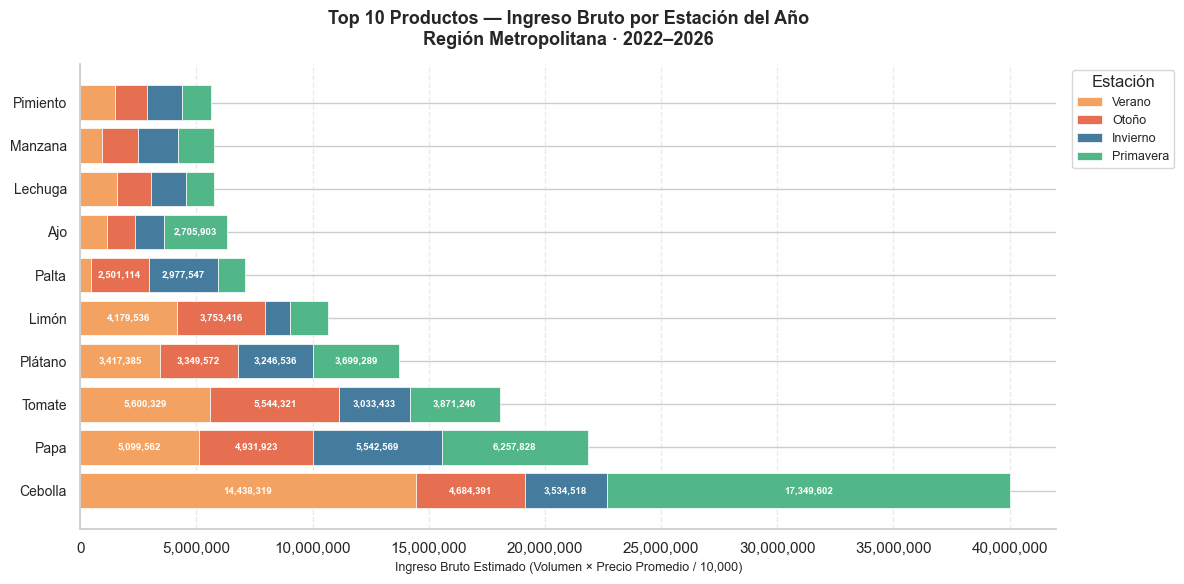

Gráfico 1 guardado ✓


In [39]:
fig, ax = plt.subplots(figsize=(12, 6))

y = np.arange(len(pivot_ib))
left = np.zeros(len(pivot_ib))

for season in SEASON_ORDER:
    valores = pivot_ib[season].values
    bars = ax.barh(y, valores, left=left,
                   color=SEASON_COLORS[season], label=season,
                   edgecolor='white', linewidth=0.5)
    # Etiqueta dentro del segmento si es suficientemente ancho
    for rect, val in zip(bars, valores):
        w = rect.get_width()
        if w > pivot_ib.values.sum(axis=1).max() * 0.05:
            ax.text(rect.get_x() + w / 2, rect.get_y() + rect.get_height() / 2,
                    f'{val:,.0f}', ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')
    left += valores

ax.set_yticks(y)
ax.set_yticklabels(pivot_ib.index, fontsize=10)
ax.set_xlabel('Ingreso Bruto Estimado (Volumen × Precio Promedio / 10,000)', fontsize=9)
ax.set_title('Top 10 Productos — Ingreso Bruto por Estación del Año\nRegión Metropolitana · 2022–2026',
             fontsize=13, fontweight='bold', pad=14)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(title='Estación', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('grafico1_barras_apiladas.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico 1 guardado ✓')

---
## Gráfico 2 — Heatmap: Intensidad de Ingreso Bruto (Producto × Estación)

### ¿Por qué este tipo de gráfico?

El **mapa de calor (heatmap)** es ideal cuando queremos detectar **patrones de intensidad en una matriz** de dos variables categóricas: producto y estación.

Mientras las barras apiladas son buenas para comparar totales, el heatmap permite **ver de un vistazo** en qué combinación producto–estación se concentra o escasea el ingreso bruto. La gradiente de color (de blanco/amarillo a rojo oscuro) activa la percepción visual de forma intuitiva: *lo más rojo, lo más rentable*.

> **Mensaje central:** *El heatmap revela qué estaciones «encienden» a cada producto — por ejemplo, si un producto es rojo en Verano y pálido en Invierno, su estacionalidad es clara y explotable.*

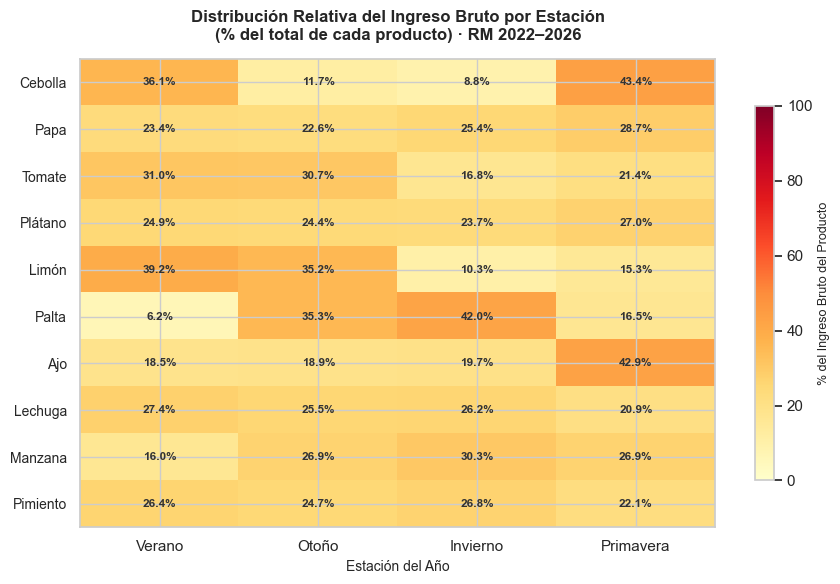

Gráfico 2 guardado ✓


In [40]:
fig, ax = plt.subplots(figsize=(9, 6))

data_matrix = pivot_ib.values
# Normalizar por fila para que cada producto muestre su distribución relativa
row_sums = data_matrix.sum(axis=1, keepdims=True)
data_norm = np.where(row_sums > 0, data_matrix / row_sums * 100, 0)

im = ax.imshow(data_norm, aspect='auto', cmap='YlOrRd', vmin=0, vmax=100)

ax.set_xticks(range(len(SEASON_ORDER)))
ax.set_xticklabels(SEASON_ORDER, fontsize=11)
ax.set_yticks(range(len(pivot_ib)))
ax.set_yticklabels(pivot_ib.index, fontsize=10)

for i in range(len(pivot_ib)):
    for j in range(len(SEASON_ORDER)):
        val = data_norm[i, j]
        color = 'white' if val > 55 else '#333333'
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                fontsize=8.5, color=color, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('% del Ingreso Bruto del Producto', fontsize=9)

ax.set_title('Distribución Relativa del Ingreso Bruto por Estación\n(% del total de cada producto) · RM 2022–2026',
             fontsize=12, fontweight='bold', pad=14)
ax.set_xlabel('Estación del Año', fontsize=10)

plt.tight_layout()
plt.savefig('grafico2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico 2 guardado ✓')

---
## Gráfico 3 — Barras agrupadas: Volumen vs. Ingreso Bruto (Top 10)

### ¿Por qué este tipo de gráfico?

Las **barras agrupadas doble-eje** permiten comparar directamente **volumen e ingreso bruto** para el mismo producto. Dado que no tenemos costo de producción, este gráfico ayuda a detectar si un producto es **eficiente en precio** (poco volumen pero mucho ingreso) versus **eficiente en cantidad** (mucho volumen pero precio bajo).

El doble eje Y es necesario porque las escalas de volumen y de ingreso son distintas, pero querer verlos juntos es legítimo aquí porque la pregunta es precisamente esa relación.

> **Mensaje central:** *Algunos productos como Tomate generan alto ingreso por volumen moderado (precio unitario alto), mientras otros requieren grandes volúmenes para alcanzar ingresos similares.*

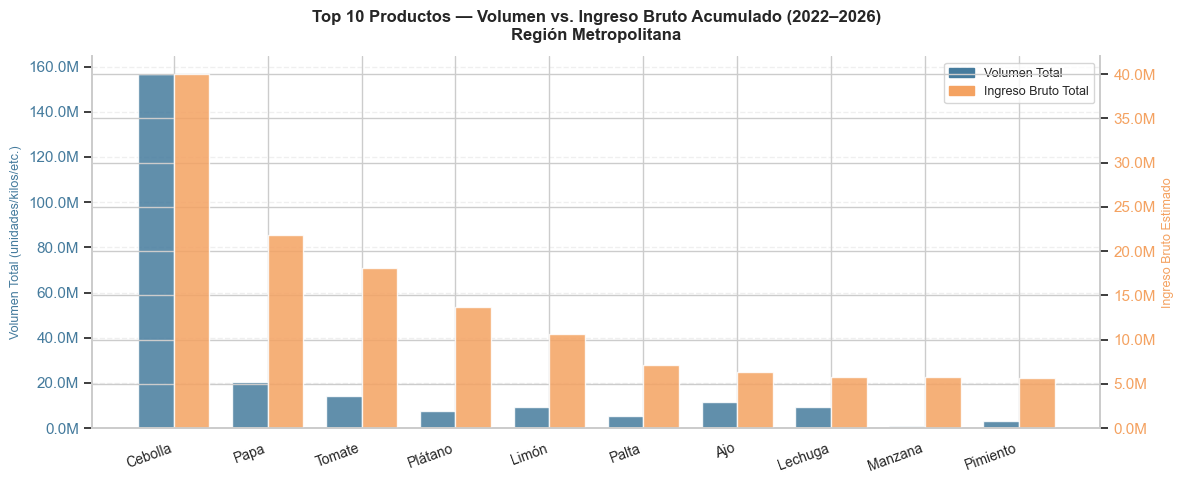

Gráfico 3 guardado ✓


In [41]:
resumen = (
    frutas_rm[frutas_rm['Producto'].isin(top10)]
    .groupby('Producto')
    .agg(Volumen_Total=('Volumen','sum'), Ingreso_Total=('Ingreso Bruto','sum'))
    .loc[pivot_ib.index]
)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

x = np.arange(len(resumen))
w = 0.38

b1 = ax1.bar(x - w/2, resumen['Volumen_Total'], width=w,
             color='#457B9D', alpha=0.85, label='Volumen Total')
b2 = ax2.bar(x + w/2, resumen['Ingreso_Total'], width=w,
             color='#F4A261', alpha=0.85, label='Ingreso Bruto Total')

ax1.set_xticks(x)
ax1.set_xticklabels(resumen.index, rotation=20, ha='right', fontsize=10)
ax1.set_ylabel('Volumen Total (unidades/kilos/etc.)', color='#457B9D', fontsize=9)
ax2.set_ylabel('Ingreso Bruto Estimado', color='#F4A261', fontsize=9)
ax1.tick_params(axis='y', labelcolor='#457B9D')
ax2.tick_params(axis='y', labelcolor='#F4A261')

ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

lines = [mpatches.Patch(color='#457B9D', label='Volumen Total'),
         mpatches.Patch(color='#F4A261', label='Ingreso Bruto Total')]
ax1.legend(handles=lines, loc='upper right', fontsize=9)

ax1.set_title('Top 10 Productos — Volumen vs. Ingreso Bruto Acumulado (2022–2026)\nRegión Metropolitana',
              fontsize=12, fontweight='bold', pad=12)
ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('grafico3_volumen_vs_ingreso.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico 3 guardado ✓')

---
## Gráfico 4 — Línea temporal: Ingreso Bruto mensual (Top 5 productos)

### ¿Por qué este tipo de gráfico?

El **gráfico de líneas temporales** es el más efectivo para mostrar **tendencias y estacionalidad a lo largo del tiempo**. Al usar el mes como eje X y superponer los 5 productos con mayor ingreso, se puede leer directamente:

- Los **picos estacionales** de cada producto (¿en qué mes generan más ingreso?).
- Si los productos compiten por el mismo periodo de alta demanda o se **complementan** a lo largo del año.
- La **consistencia o volatilidad** del ingreso mes a mes.

Las bandas de fondo identifican las estaciones del año para que la lectura sea inmediata sin necesidad de conocer el calendario astronómico del hemisferio sur.

> **Mensaje central:** *Las líneas revelan qué productos son «de temporada» (pico pronunciado en pocos meses) versus qué productos tienen demanda constante durante el año.*

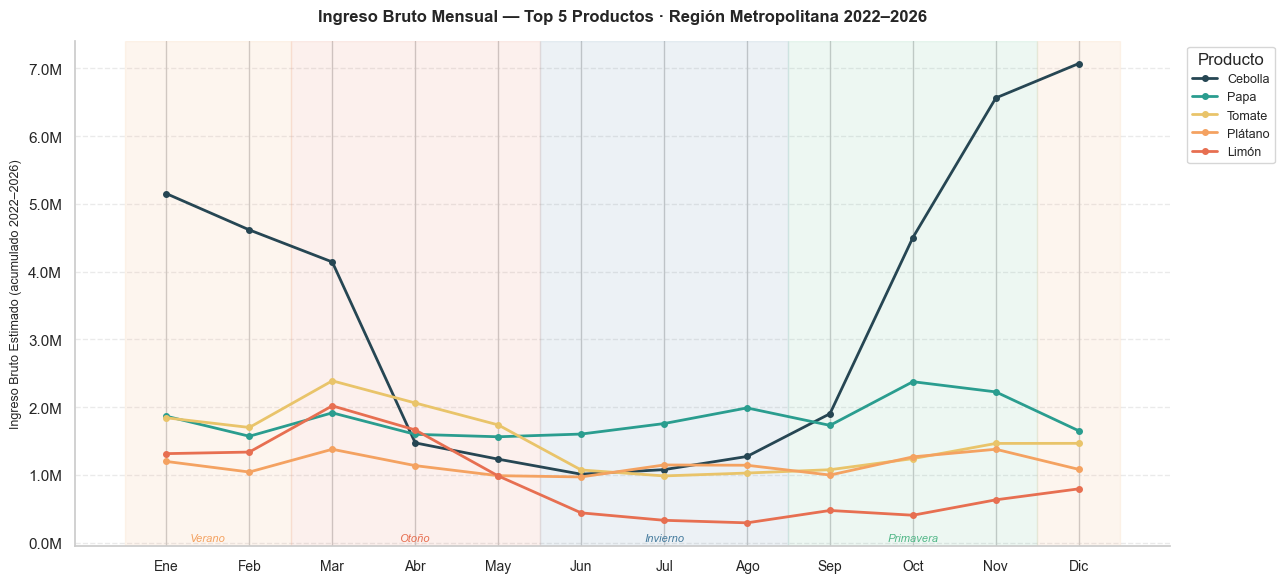

Gráfico 4 guardado ✓


In [42]:
top5 = pivot_ib.sum(axis=1).nlargest(5).index.tolist()

monthly = (
    frutas_rm[frutas_rm['Producto'].isin(top5)]
    .groupby(['Producto','Month'])['Ingreso Bruto']
    .sum()
    .unstack('Producto')
    .reindex(range(1, 13), fill_value=0)
)

MONTH_LABELS = ['Ene','Feb','Mar','Abr','May','Jun',
                'Jul','Ago','Sep','Oct','Nov','Dic']

# Bandas de estación (hemisferio sur)
# Verano: dic(12)–mar(3) => franjas al inicio y fin
SEASON_BANDS = [
    (1,  2,  'Verano',    '#F4A261'),
    (3,  5,  'Otoño',     '#E76F51'),
    (6,  8,  'Invierno',  '#457B9D'),
    (9,  11, 'Primavera', '#52B788'),
    (12, 12, 'Verano',    '#F4A261'),
]

LINE_COLORS = ['#264653','#2A9D8F','#E9C46A','#F4A261','#E76F51']

fig, ax = plt.subplots(figsize=(13, 6))

# Bandas de fondo
for m_start, m_end, label, color in SEASON_BANDS:
    ax.axvspan(m_start - 0.5, m_end + 0.5, alpha=0.10, color=color)
    if m_start != 12:   # no duplicar etiqueta de Verano
        ax.text((m_start + m_end) / 2, ax.get_ylim()[1],
                label, ha='center', va='bottom',
                fontsize=8, color=color, fontstyle='italic')

for i, prod in enumerate(top5):
    ax.plot(monthly.index, monthly[prod],
            marker='o', markersize=4,
            color=LINE_COLORS[i], linewidth=2,
            label=prod)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_LABELS, fontsize=10)
ax.set_ylabel('Ingreso Bruto Estimado (acumulado 2022–2026)', fontsize=9)
ax.set_title('Ingreso Bruto Mensual — Top 5 Productos · Región Metropolitana 2022–2026',
             fontsize=12, fontweight='bold', pad=14)
ax.legend(title='Producto', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('grafico4_lineas_temporales.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico 4 guardado ✓')

---
## Resumen de decisiones de visualización

| Gráfico | Tipo | ¿Por qué este formato? |
|---------|------|------------------------|
| **1** | Barras apiladas horizontales | Compara totales Y composición por estación en una sola lectura. Horizontal por nombres largos. |
| **2** | Heatmap (matriz de calor) | Detecta patrones de intensidad en la combinación producto×estación. Lectura visual inmediata de concentración. |
| **3** | Barras agrupadas doble eje | Pone en perspectiva si el ingreso viene del precio o del volumen, sin costo de producción disponible. |
| **4** | Líneas temporales con bandas | Muestra tendencias mes a mes y estacionalidad real. Las bandas contextualizan hemisferio sur sin texto adicional. |

### Limitación importante
El **Ingreso Bruto** aquí calculado es `Volumen × Precio Promedio / 10,000`. **No es ganancia neta**, ya que no contamos con el costo de producción o adquisición. Sin embargo, sirve como *proxy* para identificar qué productos y qué épocas del año son más relevantes comercialmente dentro del mercado mayorista de la Región Metropolitana.


# Entrega 2


asd

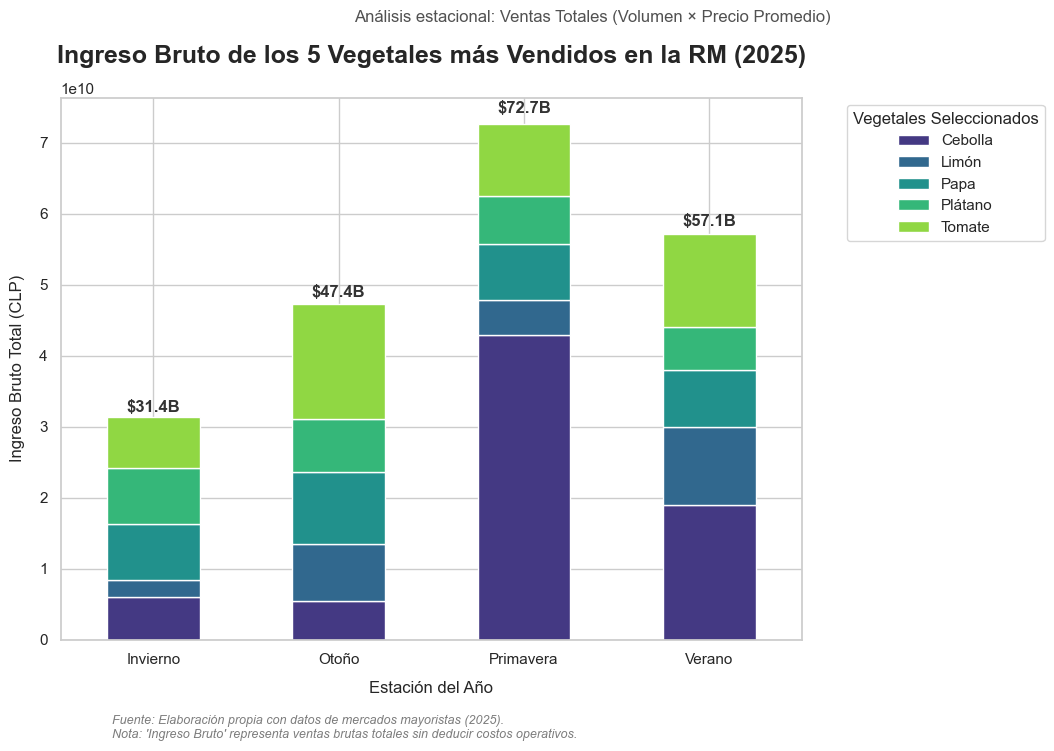

In [43]:

import seaborn as sns

# 1. Carga y Limpieza de Datos
# Usamos el archivo de 2025 para mantener la coherencia con tu propuesta original
df = pd.read_csv('precio_mayorista_fruta-hortaliza_2025.csv')

# Convertimos precios a números (manejando la coma decimal de los CSV)
df['Precio promedio'] = df['Precio promedio'].str.replace(',', '.').astype(float)
df['Volumen'] = pd.to_numeric(df['Volumen'], errors='coerce')

# 2. Filtrado para la Región Metropolitana y Productos Seleccionados
selected_products = ['Papa', 'Plátano', 'Tomate', 'Cebolla', 'Limón']
df_rm = df[df['Region'].str.contains('Metropolitana', na=False)].copy()
df_rm = df_rm[df_rm['Producto'].isin(selected_products)]

# 3. Definición de Estaciones del Año
df_rm['Fecha'] = pd.to_datetime(df_rm['Fecha'])
def get_season(month):
    if month in [1, 2, 3]: return 'Verano'
    if month in [4, 5, 6]: return 'Otoño'
    if month in [7, 8, 9]: return 'Invierno'
    return 'Primavera'

df_rm['Estacion'] = df_rm['Fecha'].dt.month.map(get_season)

# 4. Cálculo del Ingreso Bruto (Métrica solicitada)
# Definición: Volumen total transado multiplicado por el precio promedio
df_rm['Ingreso Bruto'] = df_rm['Volumen'] * df_rm['Precio promedio']

# 5. Preparación para el Gráfico de Barras Apiladas
season_order = ['Invierno', 'Otoño', 'Primavera', 'Verano']
plot_data = df_rm.groupby(['Estacion', 'Producto'])['Ingreso Bruto'].sum().unstack().reindex(season_order)

# 6. Configuración Visual y Gráfico
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 8))

# Creamos el gráfico de barras apiladas para mejorar la comparación
plot_data.plot(kind='bar', stacked=True, color=sns.color_palette("viridis", len(selected_products)), ax=ax)

# --- MEJORAS DE JERARQUÍA Y CLARIDAD ---
plt.title('Ingreso Bruto de los 5 Vegetales más Vendidos en la RM (2025)', fontsize=18, fontweight='bold', pad=25)
plt.suptitle('Análisis estacional: Ventas Totales (Volumen × Precio Promedio)', fontsize=12, y=0.93, alpha=0.8)
plt.xlabel('Estación del Año', fontsize=12, labelpad=10)
plt.ylabel('Ingreso Bruto Total (CLP)', fontsize=12, labelpad=10)
plt.xticks(rotation=0)

# 7. Direct Labeling (Etiquetas de valor directo)
# Mostramos el total por estación en miles de millones (Billions) para legibilidad
for i, (idx, row) in enumerate(plot_data.iterrows()):
    total = row.sum()
    ax.text(i, total + (total * 0.02), f'${total/1e9:.1f}B', ha='center', fontweight='bold', color='#333333')

# 8. Fuente y Nota al pie (Elemento secundario)
plt.figtext(0.1, 0.02, "Fuente: Elaboración propia con datos de mercados mayoristas (2025). \nNota: 'Ingreso Bruto' representa ventas brutas totales sin deducir costos operativos.", 
            fontsize=9, style='italic', alpha=0.6)

plt.legend(title='Vegetales Seleccionados', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0.05, 0.9, 0.95])

plt.show()

In [44]:
import pandas as pd
import plotly.express as px

# 1. Preparación de datos (Basado en tu archivo 2025)
df = pd.read_csv('precio_mayorista_fruta-hortaliza_2025.csv')
df['Precio promedio'] = df['Precio promedio'].str.replace(',', '.').astype(float)
df['Volumen'] = pd.to_numeric(df['Volumen'], errors='coerce')

selected_products = ['Papa', 'Plátano', 'Tomate', 'Cebolla', 'Limón']
df_rm = df[df['Region'].str.contains('Metropolitana', na=False)].copy()
df_rm = df_rm[df_rm['Producto'].isin(selected_products)]

# Estaciones
df_rm['Fecha'] = pd.to_datetime(df_rm['Fecha'])
def get_season(month):
    if month in [1, 2, 3]: return 'Verano'
    if month in [4, 5, 6]: return 'Otoño'
    if month in [7, 8, 9]: return 'Invierno'
    return 'Primavera'

df_rm['Estacion'] = df_rm['Fecha'].dt.month.map(get_season)
df_rm['Ingreso Bruto'] = df_rm['Volumen'] * df_rm['Precio promedio']

# Agrupar para el gráfico
season_order = ['Invierno', 'Otoño', 'Primavera', 'Verano']
df_plot = df_rm.groupby(['Estacion', 'Producto'])['Ingreso Bruto'].sum().reset_index()
df_plot['Estacion'] = pd.Categorical(df_plot['Estacion'], categories=season_order, ordered=True)
df_plot = df_plot.sort_values('Estacion')

# 2. Creación del Gráfico Interactivo con Plotly
fig = px.bar(df_plot, x="Estacion", y="Ingreso Bruto", color="Producto",
             title="<b>Ingreso Bruto Estacional en la RM (2025)</b>",
             labels={"Ingreso Bruto": "Ingreso Bruto (CLP)", "Estacion": "Estación"},
             template="plotly_white",
             category_orders={"Estacion": season_order})

# Configuración de Tooltips (Detalles bajo demanda)
fig.update_traces(hovertemplate="<b>%{label}</b><br>Producto: %{fullData.name}<br>Ingreso: $%{value:,.0f}<extra></extra>")

# Mejoras de diseño (Jerarquía)
fig.update_layout(
    title_font_size=24,
    legend_title_text='Productos',
    xaxis_title_font_size=14,
    yaxis_title_font_size=14,
    margin=dict(t=80, b=80)
)

fig.show()

In [45]:

import plotly.graph_objects as go

# 1. Preparación de datos (Igual a la versión anterior)
df = pd.read_csv('precio_mayorista_fruta-hortaliza_2025.csv')
df['Precio promedio'] = df['Precio promedio'].str.replace(',', '.').astype(float)
df['Volumen'] = pd.to_numeric(df['Volumen'], errors='coerce')
df['Fecha'] = pd.to_datetime(df['Fecha'])

def get_season(month):
    if month in [1, 2, 3]: return 'Verano'
    if month in [4, 5, 6]: return 'Otoño'
    if month in [7, 8, 9]: return 'Invierno'
    return 'Primavera'

df['Estacion'] = df['Fecha'].dt.month.map(get_season)
df['Ingreso_Bruto'] = df['Volumen'] * df['Precio promedio']
df_rm = df[df['Region'].str.contains('Metropolitana', na=False)].copy()

def get_top_10_data(estacion):
    data = df_rm[df_rm['Estacion'] == estacion]
    top_10 = data.groupby('Producto').agg({
        'Ingreso_Bruto': 'sum',
        'Volumen': 'sum'
    }).sort_values('Ingreso_Bruto', ascending=False).head(10)
    
    total_estacion = data['Ingreso_Bruto'].sum()
    top_10['Market_Share'] = (top_10['Ingreso_Bruto'] / total_estacion) * 100
    return top_10.reset_index()

seasons = ['Invierno', 'Otoño', 'Primavera', 'Verano']
seasonal_data = {s: get_top_10_data(s) for s in seasons}

# 2. Construcción del Gráfico
fig = go.Figure()

for i, season in enumerate(seasons):
    d = seasonal_data[season]
    hover_info = list(zip(d['Market_Share'], d['Volumen']))
    
    fig.add_trace(
        go.Bar(
            x=d['Producto'],
            y=d['Ingreso_Bruto'],
            name=season,
            visible=(i == 0),
            marker=dict(color=d['Ingreso_Bruto'], colorscale='Viridis'),
            customdata=hover_info, 
            hovertemplate=(
                "<b>Producto: %{x}</b><br>" +
                "Ingreso Bruto: $%{y:,.0f}<br>" +
                "Participación: %{customdata[0]:.2f}%<br>" +
                "Volumen: %{customdata[1]:,.0f} kg<br>" +
                "<extra></extra>"
            )
        )
    )

# 3. Configuración del Menú LATERAL
buttons = []
for i, season in enumerate(seasons):
    visibility = [False] * len(seasons)
    visibility[i] = True
    buttons.append(dict(
        label=season,
        method="update",
        args=[{"visible": visibility},
              {"title": f"Top 10 Productos con Mayor Ingreso Bruto en {season}"}]
    ))

fig.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        direction="down",
        showactive=True,
        x=1.15,        # <--- Posición a la derecha del gráfico
        xanchor="left",
        y=0.9,         # <--- Centrado verticalmente hacia arriba
        yanchor="top"
    )],
    title=dict(
        text=f"Top 10 Productos con Mayor Ingreso Bruto en {seasons[0]}",
        x=0.5,
        xanchor='center'
    ),
    margin=dict(r=150), # <--- Espacio extra a la derecha para que quepa el menú
    template="plotly_white",
    xaxis_title="Producto",
    yaxis_title="Ingreso Bruto (CLP)"
)

fig.show()

In [46]:
print(fig.to_html(full_html=False, include_plotlyjs='cdn'))

<div>                        <script>window.PlotlyConfig = {MathJaxConfig: 'local'};</script>
        <script charset="utf-8" src="https://cdn.plot.ly/plotly-3.4.0.min.js" integrity="sha256-KEmPoupLpFyGMyGAiOsiNDbKDKAvxXAn/W+oQa0ZAfk=" crossorigin="anonymous"></script>                <div id="937e0928-568c-4cab-92c3-5728fd532c55" class="plotly-graph-div" style="height:100%; width:100%;"></div>            <script>                window.PLOTLYENV=window.PLOTLYENV || {};                                if (document.getElementById("937e0928-568c-4cab-92c3-5728fd532c55")) {                    Plotly.newPlot(                        "937e0928-568c-4cab-92c3-5728fd532c55",                        [{"customdata":[[9.338184129655936,511021],[8.677590533021979,369327],[8.664516369740305,1309160],[7.928473229476958,673794],[6.6192302207726454,1250456],[5.220858531553441,71944],[3.4757349378829643,566220],[3.422180914659048,549079],[3.3840979360387413,155210],[3.0224199996355403,181103]],"hovertempla

In [ ]:
<script charset="utf-8" src="https://cdn.plot.ly/plotly-3.4.0.min.js" 
integrity="sha256-KEmPoupLpFyGMyGAiOsiNDbKDKAvxXAn/W+oQa0ZAfk=" crossorigin="anonymous"></script>
<div id="937e0928-568c-4cab-92c3-5728fd532c55" class="plotly-graph-div" style="height:100%; width:100%;"></div>
<script>                window.PLOTLYENV=window.PLOTLYENV || {}; 
if (document.getElementById("937e0928-568c-4cab-92c3-5728fd532c55")) {                    Plotly.newPlot(                        "937e0928-568c-4cab-92c3-5728fd532c55",                        [{"customdata":[[9.338184129655936,511021],[8.677590533021979,369327],[8.664516369740305,1309160],[7.928473229476958,673794],[6.6192302207726454,1250456],[5.220858531553441,71944],[3.4757349378829643,566220],[3.422180914659048,549079],[3.3840979360387413,155210],[3.0224199996355403,181103]],"hovertemplate":"\u003cb\u003eProducto: %{x}\u003c\u002fb\u003e\u003cbr\u003eIngreso Bruto: $%{y:,.0f}\u003cbr\u003eParticipaci\u00f3n: %{customdata[0]:.2f}%\u003cbr\u003eVolumen: %{customdata[1]:,.0f} kg\u003cbr\u003e\u003cextra\u003e\u003c\u002fextra\u003e","marker":{"color":{"dtype":"f8","bdata":"F9n1kLGQ\u002f0FKey5qDlX9QUjhTCO+Sf1BIbDz5NDM+kE3iTmM4F\u002f2Qc4Ze9DPpfFBXrqphGB\u002f50Eep5A4sSLnQUGCkmzI4OZBcT3qv9Vu5EE="},"colorscale":[[0.0,"#440154"],[0.1111111111111111,"#482878"],[0.2222222222222222,"#3e4989"],[0.3333333333333333,"#31688e"],[0.4444444444444444,"#26828e"],[0.5555555555555556,"#1f9e89"],[0.6666666666666666,"#35b779"],[0.7777777777777778,"#6ece58"],[0.8888888888888888,"#b5de2b"],[1.0,"#fde725"]]},"name":"Invierno","visible":true,"x":["Palta","Pl\u00e1tano","Papa","Tomate","Cebolla","Manzana","Zanahoria","Lechuga","Pimiento","Ajo"],"y":{"dtype":"f8","bdata":"F9n1kLGQ\u002f0FKey5qDlX9QUjhTCO+Sf1BIbDz5NDM+kE3iTmM4F\u002f2Qc4Ze9DPpfFBXrqphGB\u002f50Eep5A4sSLnQUGCkmzI4OZBcT3qv9Vu5EE="},"type":"bar"},{"customdata":[[16.082223716579623,901881],[10.00894094737478,1485750],[7.9379330765659315,686415],[7.345425758061134,370500],[5.487102965769737,1545478],[4.277226680712469,407664],[3.630879614698944,170095],[3.3047626330476336,220735],[3.0581177331673985,536638],[2.932857362198995,51664]],"hovertemplate":"\u003cb\u003eProducto: %{x}\u003c\u002fb\u003e\u003cbr\u003eIngreso Bruto: $%{y:,.0f}\u003cbr\u003eParticipaci\u00f3n: %{customdata[0]:.2f}%\u003cbr\u003eVolumen: %{customdata[1]:,.0f} kg\u003cbr\u003e\u003cextra\u003e\u003c\u002fextra\u003e","marker":{"color":{"dtype":"f8","bdata":"8kEhl\u002fNGDkLwpx3a4tcCQspU3PN+4\u002f1BIbCVdV6o+0F0JDdgGqn0Qef7h3jiGvBBF9n2tbhX60HTvEnuBePoQW3FtJWIB+dBio76fw0W5kE="},"colorscale":[[0.0,"#440154"],[0.1111111111111111,"#482878"],[0.2222222222222222,"#3e4989"],[0.3333333333333333,"#31688e"],[0.4444444444444444,"#26828e"],[0.5555555555555556,"#1f9e89"],[0.6666666666666666,"#35b779"],[0.7777777777777778,"#6ece58"],[0.8888888888888888,"#b5de2b"],[1.0,"#fde725"]]},"name":"Oto\u00f1o","visible":false,"x":["Tomate","Papa","Lim\u00f3n","Pl\u00e1tano","Cebolla","Palta","Ajo","Pimiento","Lechuga","Manzana"],"y":{"dtype":"f8","bdata":"8kEhl\u002fNGDkLwpx3a4tcCQspU3PN+4\u002f1BIbCVdV6o+0F0JDdgGqn0Qef7h3jiGvBBF9n2tbhX60HTvEnuBePoQW3FtJWIB+dBio76fw0W5kE="},"type":"bar"},{"customdata":[[30.002654589992588,20499160],[7.082859249432325,772064],[5.533404819771637,1261898],[4.9872558351448415,2788102],[4.713508681328086,306821],[3.4123224545676996,582614],[2.9880697747373417,56227],[2.6169236755425125,352947],[2.4281296569528448,602948],[2.307861409756539,105097]],"hovertemplate":"\u003cb\u003eProducto: %{x}\u003c\u002fb\u003e\u003cbr\u003eIngreso Bruto: $%{y:,.0f}\u003cbr\u003eParticipaci\u00f3n: %{customdata[0]:.2f}%\u003cbr\u003eVolumen: %{customdata[1]:,.0f} kg\u003cbr\u003e\u003cextra\u003e\u003c\u002fextra\u003e","marker":{"color":{"dtype":"f8","bdata":"7JFaL3EEJEKP5Naw\u002f+YCQsRCy+TTiP1BqvHoRZKe+kElddgqhij5QZVlAE+WNvJBuB77c8fl70Hjpalmg+\u002frQU5iGACU6+lB7ziV5+ii6EE="},"colorscale":[[0.0,"#440154"],[0.1111111111111111,"#482878"],[0.2222222222222222,"#3e4989"],[0.3333333333333333,"#31688e"],[0.4444444444444444,"#26828e"],[0.5555555555555556,"#1f9e89"],[0.6666666666666666,"#35b779"],[0.7777777777777778,"#6ece58"],[0.8888888888888888,"#b5de2b"],[1.0,"#fde725"]]},"name":"Primavera","visible":false,"x":["Cebolla","Tomate","Papa","Ajo","Pl\u00e1tano","Lim\u00f3n","Manzana","Palta","Zanahoria","Poroto verde"],"y":{"dtype":"f8","bdata":"7JFaL3EEJEKP5Naw\u002f+YCQsRCy+TTiP1BqvHoRZKe+kElddgqhij5QZVlAE+WNvJBuB77c8fl70Hjpalmg+\u002frQU5iGACU6+lB7ziV5+ii6EE="},"type":"bar"},{"customdata":[[16.77863617705415,12495211],[11.50365756394511,1060024],[9.577635759493683,673591],[7.065917683152874,1399292],[5.380284960253228,289175],[3.249045917187088,165073],[3.126754119019009,263336],[2.5375036622233247,461343],[2.4305648598184577,15379500],[2.3776996934993995,457051]],"hovertemplate":"\u003cb\u003eProducto: %{x}\u003c\u002fb\u003e\u003cbr\u003eIngreso Bruto: $%{y:,.0f}\u003cbr\u003eParticipaci\u00f3n: %{customdata[0]:.2f}%\u003cbr\u003eVolumen: %{customdata[1]:,.0f} kg\u003cbr\u003e\u003cextra\u003e\u003c\u002fextra\u003e","marker":{"color":{"dtype":"f8","bdata":"ITCq5oW9EUJyChw\u002fdVMIQjk09F\u002fQQARChxb5Fzbi\u002fUEAAPzGMMH2QQyTbU9ue+tBETYWS59y6kEWamM\u002fq3blQSlcn\u002fsaj+RBfGEQzaEc5EE="},"colorscale":[[0.0,"#440154"],[0.1111111111111111,"#482878"],[0.2222222222222222,"#3e4989"],[0.3333333333333333,"#31688e"],[0.4444444444444444,"#26828e"],[0.5555555555555556,"#1f9e89"],[0.6666666666666666,"#35b779"],[0.7777777777777778,"#6ece58"],[0.8888888888888888,"#b5de2b"],[1.0,"#fde725"]]},"name":"Verano","visible":false,"x":["Cebolla","Tomate","Lim\u00f3n","Papa","Pl\u00e1tano","Poroto granado","Pimiento","Lechuga","Choclo","Zanahoria"],"y":{"dtype":"f8","bdata":"ITCq5oW9EUJyChw\u002fdVMIQjk09F\u002fQQARChxb5Fzbi\u002fUEAAPzGMMH2QQyTbU9ue+tBETYWS59y6kEWamM\u002fq3blQSlcn\u002fsaj+RBfGEQzaEc5EE="},"type":"bar"}],                        {"template":{"data":{"barpolar":[{"marker":{"line":{"color":"white","width":0.5},"pattern":{"fillmode":"overlay","size":10,"solidity":0.2}},"type":"barpolar"}],"bar":[{"error_x":{"color":"#2a3f5f"},"error_y":{"color":"#2a3f5f"},"marker":{"line":{"color":"white","width":0.5},"pattern":{"fillmode":"overlay","size":10,"solidity":0.2}},"type":"bar"}],"carpet":[{"aaxis":{"endlinecolor":"#2a3f5f","gridcolor":"#C8D4E3","linecolor":"#C8D4E3","minorgridcolor":"#C8D4E3","startlinecolor":"#2a3f5f"},"baxis":{"endlinecolor":"#2a3f5f","gridcolor":"#C8D4E3","linecolor":"#C8D4E3","minorgridcolor":"#C8D4E3","startlinecolor":"#2a3f5f"},"type":"carpet"}],"choropleth":[{"colorbar":{"outlinewidth":0,"ticks":""},"type":"choropleth"}],"contourcarpet":[{"colorbar":{"outlinewidth":0,"ticks":""},"type":"contourcarpet"}],"contour":[{"colorbar":{"outlinewidth":0,"ticks":""},"colorscale":[[0.0,"#0d0887"],[0.1111111111111111,"#46039f"],[0.2222222222222222,"#7201a8"],[0.3333333333333333,"#9c179e"],[0.4444444444444444,"#bd3786"],[0.5555555555555556,"#d8576b"],[0.6666666666666666,"#ed7953"],[0.7777777777777778,"#fb9f3a"],[0.8888888888888888,"#fdca26"],[1.0,"#f0f921"]],"type":"contour"}],"heatmap":[{"colorbar":{"outlinewidth":0,"ticks":""},"colorscale":[[0.0,"#0d0887"],[0.1111111111111111,"#46039f"],[0.2222222222222222,"#7201a8"],[0.3333333333333333,"#9c179e"],[0.4444444444444444,"#bd3786"],[0.5555555555555556,"#d8576b"],[0.6666666666666666,"#ed7953"],[0.7777777777777778,"#fb9f3a"],[0.8888888888888888,"#fdca26"],[1.0,"#f0f921"]],"type":"heatmap"}],"histogram2dcontour":[{"colorbar":{"outlinewidth":0,"ticks":""},"colorscale":[[0.0,"#0d0887"],[0.1111111111111111,"#46039f"],[0.2222222222222222,"#7201a8"],[0.3333333333333333,"#9c179e"],[0.4444444444444444,"#bd3786"],[0.5555555555555556,"#d8576b"],[0.6666666666666666,"#ed7953"],[0.7777777777777778,"#fb9f3a"],[0.8888888888888888,"#fdca26"],[1.0,"#f0f921"]],"type":"histogram2dcontour"}],"histogram2d":[{"colorbar":{"outlinewidth":0,"ticks":""},"colorscale":[[0.0,"#0d0887"],[0.1111111111111111,"#46039f"],[0.2222222222222222,"#7201a8"],[0.3333333333333333,"#9c179e"],[0.4444444444444444,"#bd3786"],[0.5555555555555556,"#d8576b"],[0.6666666666666666,"#ed7953"],[0.7777777777777778,"#fb9f3a"],[0.8888888888888888,"#fdca26"],[1.0,"#f0f921"]],"type":"histogram2d"}],"histogram":[{"marker":{"pattern":{"fillmode":"overlay","size":10,"solidity":0.2}},"type":"histogram"}],"mesh3d":[{"colorbar":{"outlinewidth":0,"ticks":""},"type":"mesh3d"}],"parcoords":[{"line":{"colorbar":{"outlinewidth":0,"ticks":""}},"type":"parcoords"}],"pie":[{"automargin":true,"type":"pie"}],"scatter3d":[{"line":{"colorbar":{"outlinewidth":0,"ticks":""}},"marker":{"colorbar":{"outlinewidth":0,"ticks":""}},"type":"scatter3d"}],"scattercarpet":[{"marker":{"colorbar":{"outlinewidth":0,"ticks":""}},"type":"scattercarpet"}],"scattergeo":[{"marker":{"colorbar":{"outlinewidth":0,"ticks":""}},"type":"scattergeo"}],"scattergl":[{"marker":{"colorbar":{"outlinewidth":0,"ticks":""}},"type":"scattergl"}],"scattermapbox":[{"marker":{"colorbar":{"outlinewidth":0,"ticks":""}},"type":"scattermapbox"}],"scattermap":[{"marker":{"colorbar":{"outlinewidth":0,"ticks":""}},"type":"scattermap"}],"scatterpolargl":[{"marker":{"colorbar":{"outlinewidth":0,"ticks":""}},"type":"scatterpolargl"}],"scatterpolar":[{"marker":{"colorbar":{"outlinewidth":0,"ticks":""}},"type":"scatterpolar"}],"scatter":[{"fillpattern":{"fillmode":"overlay","size":10,"solidity":0.2},"type":"scatter"}],"scatterternary":[{"marker":{"colorbar":{"outlinewidth":0,"ticks":""}},"type":"scatterternary"}],"surface":[{"colorbar":{"outlinewidth":0,"ticks":""},"colorscale":[[0.0,"#0d0887"],[0.1111111111111111,"#46039f"],[0.2222222222222222,"#7201a8"],[0.3333333333333333,"#9c179e"],[0.4444444444444444,"#bd3786"],[0.5555555555555556,"#d8576b"],[0.6666666666666666,"#ed7953"],[0.7777777777777778,"#fb9f3a"],[0.8888888888888888,"#fdca26"],[1.0,"#f0f921"]],"type":"surface"}],"table":[{"cells":{"fill":{"color":"#EBF0F8"},"line":{"color":"white"}},"header":{"fill":{"color":"#C8D4E3"},"line":{"color":"white"}},"type":"table"}]},"layout":{"annotationdefaults":{"arrowcolor":"#2a3f5f","arrowhead":0,"arrowwidth":1},"autotypenumbers":"strict","coloraxis":{"colorbar":{"outlinewidth":0,"ticks":""}},"colorscale":{"diverging":[[0,"#8e0152"],[0.1,"#c51b7d"],[0.2,"#de77ae"],[0.3,"#f1b6da"],[0.4,"#fde0ef"],[0.5,"#f7f7f7"],[0.6,"#e6f5d0"],[0.7,"#b8e186"],[0.8,"#7fbc41"],[0.9,"#4d9221"],[1,"#276419"]],"sequential":[[0.0,"#0d0887"],[0.1111111111111111,"#46039f"],[0.2222222222222222,"#7201a8"],[0.3333333333333333,"#9c179e"],[0.4444444444444444,"#bd3786"],[0.5555555555555556,"#d8576b"],[0.6666666666666666,"#ed7953"],[0.7777777777777778,"#fb9f3a"],[0.8888888888888888,"#fdca26"],[1.0,"#f0f921"]],"sequentialminus":[[0.0,"#0d0887"],[0.1111111111111111,"#46039f"],[0.2222222222222222,"#7201a8"],[0.3333333333333333,"#9c179e"],[0.4444444444444444,"#bd3786"],[0.5555555555555556,"#d8576b"],[0.6666666666666666,"#ed7953"],[0.7777777777777778,"#fb9f3a"],[0.8888888888888888,"#fdca26"],[1.0,"#f0f921"]]},"colorway":["#636efa","#EF553B","#00cc96","#ab63fa","#FFA15A","#19d3f3","#FF6692","#B6E880","#FF97FF","#FECB52"],"font":{"color":"#2a3f5f"},"geo":{"bgcolor":"white","lakecolor":"white","landcolor":"white","showlakes":true,"showland":true,"subunitcolor":"#C8D4E3"},"hoverlabel":{"align":"left"},"hovermode":"closest","mapbox":{"style":"light"},"paper_bgcolor":"white","plot_bgcolor":"white","polar":{"angularaxis":{"gridcolor":"#EBF0F8","linecolor":"#EBF0F8","ticks":""},"bgcolor":"white","radialaxis":{"gridcolor":"#EBF0F8","linecolor":"#EBF0F8","ticks":""}},"scene":{"xaxis":{"backgroundcolor":"white","gridcolor":"#DFE8F3","gridwidth":2,"linecolor":"#EBF0F8","showbackground":true,"ticks":"","zerolinecolor":"#EBF0F8"},"yaxis":{"backgroundcolor":"white","gridcolor":"#DFE8F3","gridwidth":2,"linecolor":"#EBF0F8","showbackground":true,"ticks":"","zerolinecolor":"#EBF0F8"},"zaxis":{"backgroundcolor":"white","gridcolor":"#DFE8F3","gridwidth":2,"linecolor":"#EBF0F8","showbackground":true,"ticks":"","zerolinecolor":"#EBF0F8"}},"shapedefaults":{"line":{"color":"#2a3f5f"}},"ternary":{"aaxis":{"gridcolor":"#DFE8F3","linecolor":"#A2B1C6","ticks":""},"baxis":{"gridcolor":"#DFE8F3","linecolor":"#A2B1C6","ticks":""},"bgcolor":"white","caxis":{"gridcolor":"#DFE8F3","linecolor":"#A2B1C6","ticks":""}},"title":{"x":0.05},"xaxis":{"automargin":true,"gridcolor":"#EBF0F8","linecolor":"#EBF0F8","ticks":"","title":{"standoff":15},"zerolinecolor":"#EBF0F8","zerolinewidth":2},"yaxis":{"automargin":true,"gridcolor":"#EBF0F8","linecolor":"#EBF0F8","ticks":"","title":{"standoff":15},"zerolinecolor":"#EBF0F8","zerolinewidth":2}}},"title":{"text":"Top 10 Productos con Mayor Ingreso Bruto en Invierno","x":0.5,"xanchor":"center"},"margin":{"r":150},"updatemenus":[{"active":0,"buttons":[{"args":[{"visible":[true,false,false,false]},{"title":"Top 10 Productos con Mayor Ingreso Bruto en Invierno"}],"label":"Invierno","method":"update"},{"args":[{"visible":[false,true,false,false]},{"title":"Top 10 Productos con Mayor Ingreso Bruto en Oto\u00f1o"}],"label":"Oto\u00f1o","method":"update"},{"args":[{"visible":[false,false,true,false]},{"title":"Top 10 Productos con Mayor Ingreso Bruto en Primavera"}],"label":"Primavera","method":"update"},{"args":[{"visible":[false,false,false,true]},{"title":"Top 10 Productos con Mayor Ingreso Bruto en Verano"}],"label":"Verano","method":"update"}],"direction":"down","showactive":true,"x":1.15,"xanchor":"left","y":0.9,"yanchor":"top"}],"xaxis":{"title":{"text":"Producto"}},"yaxis":{"title":{"text":"Ingreso Bruto (CLP)"}}},                        {"responsive": true}                    )                };            </script>        </div>